In [63]:
# R2_CAR171_Canopus.ipynb
# Estimating the stray-light from Canopus star for the Commissioning Activity Request (CAR) 171. 
# This notebook is based on the R1_Rosalia_stray_example.ipynb notebook, but it is adapted to the specific case of Canopus.
# - Alejandro S. Borlaff / NASA Ames / a.s.borlaff@nasa.gov. March 11, 2026.
import rosalia as rs
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.wcs as astropy_wcs
import matplotlib.colors as matplotlib_colors

import os
plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")


In [64]:
# Let's find Canopus (alpha Carinae), the star selected for CAR171. 
# This star is in the continuous viewing zone of Roman, and it is the second brightest star in the sky.
import astropy.units as u
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

alfCar = Simbad.query_object('Canopus')
ra_star = alfCar["ra"][0]
dec_star = alfCar["dec"][0]

target = SkyCoord(ra_star*u.deg, dec_star*u.deg, frame="icrs")
print(target)


<SkyCoord (ICRS): (ra, dec) in deg
    (95.98795783, -52.69566138)>


In [65]:
# These are the coordinates of specially sensitive locations 
# for stray-light, measured in offset degrees from the center of WFI focal plane
dX = np.array([-3.7, 3.7, 6.05, 2.45, -2.45, -6.05, -2, 2, -1.3, 1.3, -0.0688, 0.0688, -0.138, 0.138])
dY = np.array([5.27, 5.27, 1.18, -5.07, -5.07, 1.18, 6.15, 6.15, 1, 1, -0.0312, -0.0312, -0.0035, -0.0048])
number_of_points_of_interest = len(dX)
superpixel_mm2_area = (rs.telescopes.Roman.get_physical_pixelsize("WFI").to("mm").value * 512)**2


# PA 125.07221
# Length 6.411380

In [66]:
dX_primary = dX
dY_primary = dY

413.19088864245794
953.2570503979707


413.19088864245794
953.2570503979707
1.0083333333333535
[-1.  -0.5  0.   0.5  1. ]
[  0.5  30.5  60.5  90.5 120.5]


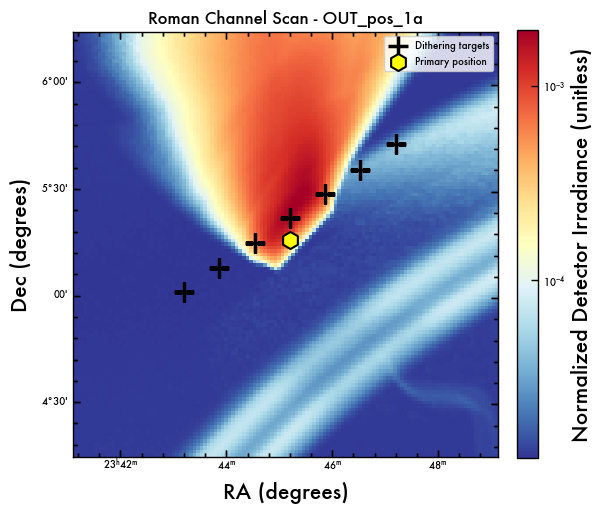

In [68]:
# Plot level 2 NDI 
ndi_name = os.environ["ROSALIACACHE"] + "CORE/NDI/RST/ndi_lvl2_mean.fits"
ndi_fits = fits.open(ndi_name)
ndi_w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
x_stars, y_stars = ndi_w.wcs_world2pix(dX[0], dY[0], 0)
print(x_stars)
print(y_stars)
# Make a crop of the region.
output_name = ndi_name.replace(".fits", "_crop_OUT1.fits")
cmd = "astcrop " + ndi_name + " -K --mode=img --center="+str(x_stars)+","+str(y_stars)+" --width=120 -h0" + " -o " +  output_name
rs.utils.execute_cmd(cmd)

ndi_cropped_name = output_name

pa_point = 0
ra_point = 0 
dec_point = 0 
ndi_linthresh = 0.0001

if True:
    # Make the modified header based on the exposure properties.
    ndi_cropped_fits = fits.open(ndi_cropped_name)

    header = ndi_cropped_fits[1].header
    data = ndi_cropped_fits[1].data
    ndi_w = astropy_wcs.WCS(header=header, fobj=ndi_cropped_fits, naxis=2)

    
    # w = astropy_wcs.WCS(header=header, fobj=ndi_fits, naxis=2)
    ndi_w.wcs.crota = -pa_point,-pa_point
    ndi_w.wcs.crval = ra_point,dec_point
    ndi_w.wcs.cdelt = header["CDELT1"],header["CDELT2"]
    header = ndi_w.to_header()

    print(x_stars)
    print(y_stars)
     
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw=dict(projection=ndi_w))


    # The transfer NDI maps units of 1/(superpixel size in mm2). 
    # We need to correct by that factor. 
    im = ax.imshow(data/superpixel_mm2_area, origin='lower', cmap="RdYlBu_r",
                   norm=matplotlib_colors.SymLogNorm(linthresh=ndi_linthresh, linscale=1,
                                            base=10))
    cbar = plt.colorbar(im, ax=ax, location='right', fraction=0.046, pad=0.04)
    cbar.set_label(label='Normalized Detector Irradiance (unitless)',size=15)


    # star_catalog = star_catalog_list[i]
    
    # CAR locations 
    alpha = 1
    if True:
        # CAR 1 A
        #dX_dithering = np.array([-0.08, -0.333, -0.2, 0.08, 0.333,  0.5]) + dX[0]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        #dY_dithering = np.array([0.10, -0.333, -0.2, 0.167, 0.333,  0.5]) + dY[0]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        #R = 0.25 # [0.25,0.25,0.25,0.25,0.25,0.25,0.25]
        #angle = np.linspace(0, 360, 4)+90
        #dX_dithering = R*np.cos(np.radians(angle)) + dX[0]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        #dY_dithering = R*np.sin(np.radians(angle)) + dY[0]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        dX_dithering = np.array([-0.5, -0.333, -0.167, 0,  0.167, 0.33,  0.5]) + dX[0]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        dY_dithering = 0.70*np.array([-0.5, -0.333, -0.167, 0,  0.167, 0.33,  0.5]) + 0.10 + dY[0]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        x_stars_dith, y_stars_dith = ndi_w.wcs_world2pix(dX_dithering, dY_dithering, 0)
        ax.scatter(x_stars_dith, y_stars_dith, marker="+", edgecolor="black", color="black", linewidth=2.5, alpha=alpha, s=200, label="Dithering targets")
        x_stars_pri, y_stars_pri = ndi_w.wcs_world2pix(dX[0], dY[0], 0)
        ax.scatter(x_stars_pri, y_stars_pri, marker="h", edgecolor="black", color="yellow", linewidth=1.5, alpha=alpha, s=150, label="Primary position")

    
    #ax.set_title("Stray-light source location on Focal Plane\n", fontsize=16)

    max_extent_ndi = np.abs(header["CDELT2"]) * data.shape[0]/2# This is the radial extent of the NDI map
    print(max_extent_ndi)
    angle_ticks = np.round(np.linspace(-max_extent_ndi, max_extent_ndi, 5),1)
    print(angle_ticks)
    pixel_ticks = angle_ticks/np.abs(header["CDELT2"])  + data.shape[0]/2
    print(pixel_ticks)
    #ax.set_xticks(pixel_ticks, angle_ticks, size=12)
    #ax.set_yticks(pixel_ticks, angle_ticks, size=12)
    ax.set_xlabel("RA (degrees)", size=15)
    ax.set_ylabel("Dec (degrees)", size=15)
    ax.set_title("Roman Channel Scan - OUT_pos_1a", size=12)
    plt.legend(frameon=True)

    plt.savefig("ndi_20deg_CAR171_OUT_1_dithering.png", dpi=300)

    dX_dithering_OUT_pos_1a = dX_dithering
    dY_dithering_OUT_pos_1a = dY_dithering

In [39]:

dXdY_pix_rogue_half = np.array([[516.45,1005.6],
[482.41623,990.80657],
[570.22558,1010.6064],
[565.76959,1042.2123],
[506.60463,1030.0492],
[473.17089,1011.6787],
[573.10477,992.57305],
[524.22551,979.58497],
[492.75619,966.19625],
[536.50481,1038.53],
[544.06326,1008.1024],
[548.32701,987.17127],
[636.5,1052.6779],
[636.5,1017.0175],
[636.5,998.60586],
[636.5 + (636.5-516.45),1005.6],
[636.5 + (636.5-482.41623),990.80657],
[636.5 + (636.5-570.22558),1010.6064],
[636.5 + (636.5-565.76959),1042.2123],
[636.5 + (636.5-506.60463),1030.0492],
[636.5 + (636.5-473.17089),1011.6787],
[636.5 + (636.5-573.10477),992.57305],
[636.5 + (636.5-524.22551),979.58497],
[636.5 + (636.5-492.75619),966.19625],
[636.5 + (636.5-536.50481),1038.53],
[636.5 + (636.5-544.06326),1008.1024],
[636.5 + (636.5-548.32701),987.17127]])

dX_rogue_half_pix = dXdY_pix_rogue_half[:,0]
dY_rogue_half_pix = dXdY_pix_rogue_half[:,1]

dX_rogue_half = (dXdY_pix_rogue_half[:,0]-636.5)*0.01666
dY_rogue_half = (dXdY_pix_rogue_half[:,1]-636.5)*0.01666

print(dX_rogue_half)
print(dY_rogue_half)



[-2.000033   -2.56703561 -1.10413184 -1.17836863 -2.16405686 -2.72106297
 -1.05616453 -1.870493   -2.39477187 -1.66591987 -1.53999609 -1.46896201
  0.          0.          0.          2.000033    2.56703561  1.10413184
  1.17836863  2.16405686  2.72106297  1.05616453  1.870493    2.39477187
  1.66591987  1.53999609  1.46896201]
[6.149206   5.90274746 6.23261262 6.75916692 6.55652967 6.25047714
 5.93217701 5.7157956  5.49273953 6.6978198  6.19089598 5.84218336
 6.93352381 6.33942155 6.03268363 6.149206   5.90274746 6.23261262
 6.75916692 6.55652967 6.25047714 5.93217701 5.7157956  5.49273953
 6.6978198  6.19089598 5.84218336]




676.9639761915226
704.0359815843022
2.0916666666667085
[-2.1 -1.   0.   1.   2.1]
[ -0.5  65.5 125.5 185.5 251.5]


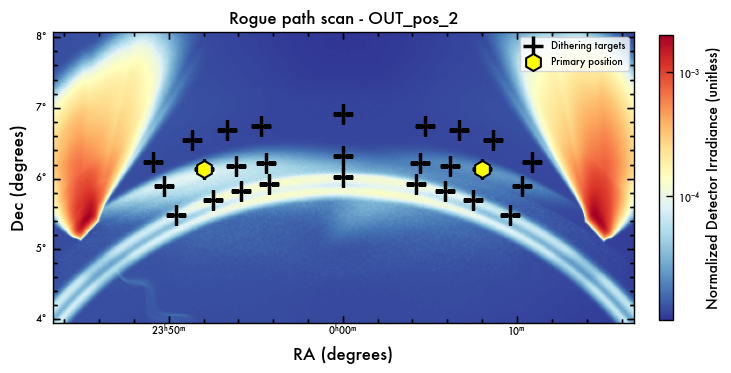

In [48]:
# Plot level 2 NDI 
ndi_name = os.environ["ROSALIACACHE"] + "CORE/NDI/RST/ndi_lvl2_mean.fits"
ndi_fits = fits.open(ndi_name)
ndi_w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)

# Make a crop of the region.
output_name = ndi_name.replace(".fits", "_crop_ROGUEPATH.fits")
cmd = "astcrop " + ndi_name + " -K --mode=img --center=636.5,1000 --width=500,250 -h0" + " -o " +  output_name
rs.utils.execute_cmd(cmd)

ndi_cropped_name = output_name

pa_point = 0
ra_point = 0 
dec_point = 0 
ndi_linthresh = 0.0001

if True:
    # Make the modified header based on the exposure properties.
    ndi_cropped_fits = fits.open(ndi_cropped_name)

    header = ndi_cropped_fits[1].header
    data = ndi_cropped_fits[1].data
    ndi_w = astropy_wcs.WCS(header=header, fobj=ndi_cropped_fits, naxis=2)

    
    # w = astropy_wcs.WCS(header=header, fobj=ndi_fits, naxis=2)
    ndi_w.wcs.crota = -pa_point,-pa_point
    ndi_w.wcs.crval = ra_point,dec_point
    ndi_w.wcs.cdelt = header["CDELT1"],header["CDELT2"]
    header = ndi_w.to_header()

    print(x_stars)
    print(y_stars)
     
    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection=ndi_w))


    # The transfer NDI maps units of 1/(superpixel size in mm2). 
    # We need to correct by that factor. 
    im = ax.imshow(data/superpixel_mm2_area, origin='lower', cmap="RdYlBu_r",
                   norm=matplotlib_colors.SymLogNorm(linthresh=ndi_linthresh, linscale=1,
                                            base=10))
    cbar = plt.colorbar(im, ax=ax, location='right', fraction=0.023, pad=0.04)
    cbar.set_label(label='Normalized Detector Irradiance (unitless)',size=10)


    # star_catalog = star_catalog_list[i]
    
    # CAR locations 
    alpha = 1
    if True:
        # CAR 1 A
        #dX_dithering = np.array([-0.08, -0.333, -0.2, 0.08, 0.333,  0.5]) + dX[0]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        #dY_dithering = np.array([0.10, -0.333, -0.2, 0.167, 0.333,  0.5]) + dY[0]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        #R = 0.25 # [0.25,0.25,0.25,0.25,0.25,0.25,0.25]
        #angle = np.linspace(0, 360, 4)+90
        #dX_dithering = R*np.cos(np.radians(angle)) + dX[0]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        #dY_dithering = R*np.sin(np.radians(angle)) + dY[0]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        dX_dithering = dX_rogue_half   # np.linspace(-0.5, 0.5, 7) + dX[0] 
        dY_dithering = dY_rogue_half  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        x_stars_dith, y_stars_dith = ndi_w.wcs_world2pix(dX_dithering, dY_dithering, 0)
        ax.scatter(x_stars_dith, y_stars_dith, marker="+", edgecolor="black", color="black", linewidth=2.5, alpha=alpha, s=200, label="Dithering targets")
    x_stars_pri, y_stars_pri = ndi_w.wcs_world2pix(dX[6:8], dY[6:8], 0)
    ax.scatter(x_stars_pri, y_stars_pri, marker="h", edgecolor="black", color="yellow", linewidth=1.5, alpha=alpha, s=150, label="Primary position")

    
    #ax.set_title("Stray-light source location on Focal Plane\n", fontsize=16)

    max_extent_ndi = np.abs(header["CDELT2"]) * data.shape[0]/2# This is the radial extent of the NDI map
    print(max_extent_ndi)
    angle_ticks = np.round(np.linspace(-max_extent_ndi, max_extent_ndi, 5),1)
    print(angle_ticks)
    pixel_ticks = angle_ticks/np.abs(header["CDELT2"])  + data.shape[0]/2
    print(pixel_ticks)
    #ax.set_xticks(pixel_ticks, angle_ticks, size=12)
    #ax.set_yticks(pixel_ticks, angle_ticks, size=12)
    ax.set_xlabel("RA (degrees)", size=12)
    ax.set_ylabel("Dec (degrees)", size=12)

    ax.set_title("Rogue path scan - OUT_pos_2", size=12)
    plt.legend(frameon=True)

    plt.savefig("ndi_20deg_CAR171_RoguePath_dithering.png", dpi=300)

676.9639761915226
704.0359815843022


676.9639761915226
704.0359815843022
0.05208333333333375
[-0.1 -0.   0.   0.   0.1]
[-34.5  37.5  37.5  37.5 109.5]


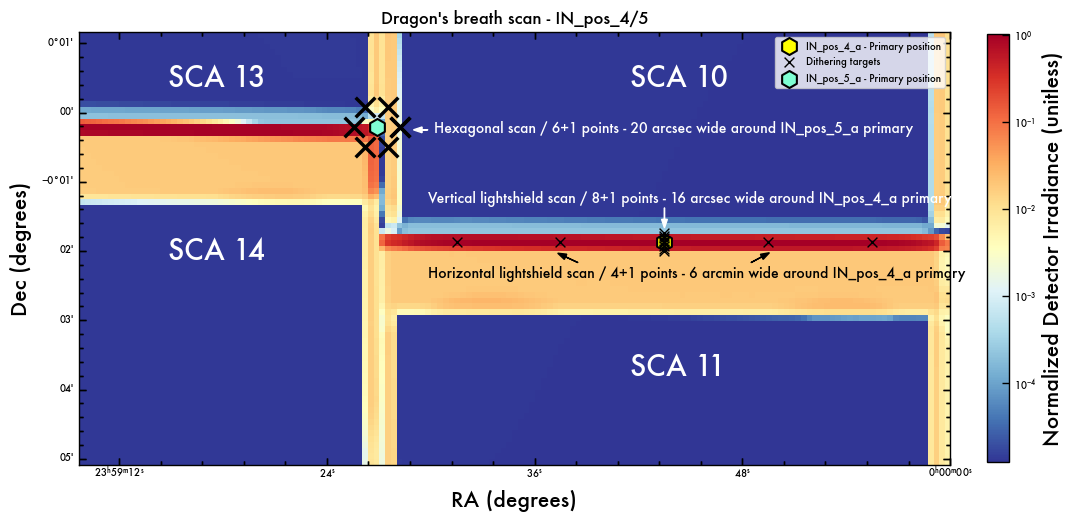

In [69]:
# Plot level 2 NDI 
ndi_name = os.environ["ROSALIACACHE"] + "CORE/NDI/RST/ndi_lvl1_mean.fits"
ndi_fits = fits.open(ndi_name)
ndi_w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
x_stars, y_stars = ndi_w.wcs_world2pix(dX[10], dY[10], 0)
print(x_stars)
print(y_stars)
# Make a crop of the region.
output_name = ndi_name.replace(".fits", "_crop_IN_4a.fits")
cmd = "astcrop " + ndi_name + " -K --mode=img --center="+str(x_stars-25)+","+str(y_stars)+" --width=150,75 -h0" + " -o " +  output_name
rs.utils.execute_cmd(cmd)

ndi_cropped_name = output_name

pa_point = 0
ra_point = 0 
dec_point = 0 
ndi_linthresh = 0.0001

if True:
    # Make the modified header based on the exposure properties.
    ndi_cropped_fits = fits.open(ndi_cropped_name)

    header = ndi_cropped_fits[1].header
    data = ndi_cropped_fits[1].data
    ndi_w = astropy_wcs.WCS(header=header, fobj=ndi_cropped_fits, naxis=2)

    
    # w = astropy_wcs.WCS(header=header, fobj=ndi_fits, naxis=2)
    ndi_w.wcs.crota = -pa_point,-pa_point
    ndi_w.wcs.crval = ra_point,dec_point
    ndi_w.wcs.cdelt = header["CDELT1"],header["CDELT2"]
    header = ndi_w.to_header()

    print(x_stars)
    print(y_stars)
     
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw=dict(projection=ndi_w))


    # The transfer NDI maps units of 1/(superpixel size in mm2). 
    # We need to correct by that factor. 
    im = ax.imshow(data/superpixel_mm2_area, origin='lower', cmap="RdYlBu_r",
                   norm=matplotlib_colors.SymLogNorm(linthresh=ndi_linthresh, linscale=1,
                                            base=10))
    cbar = plt.colorbar(im, ax=ax, location='right', fraction=0.023, pad=0.04)
    cbar.set_label(label='Normalized Detector Irradiance (unitless)',size=15)


    # star_catalog = star_catalog_list[i]
    
    # CAR locations 
    alpha = 1
    if True:
        # IN_POS_4_a
        center_id = 10
        #R = 20 / 60 / 60 # 20 arcsec hexagonal dithering  # [0.25,0.25,0.25,0.25,0.25,0.25,0.25]
        #angle = np.linspace(0, 360, 7)
        dX_dithering = list(np.linspace(-3/60, 3/60, 5) + dX[center_id]) + list(np.zeros((8)) + dX[center_id])  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        dY_dithering = list(np.zeros((5)) + dY[center_id]) + list(np.linspace(-8/60/60, 8/60/60, 8) + dY[center_id]) # np.linspace(-0.5, 0.5, 7) + dY[0] 
        #dX_dithering = np.array([-0.5, -0.333, -0.167, 0,  0.167, 0.33,  0.5]) + dX[center_id]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        # dY_dithering = 0.70*np.array([-0.5, -0.333, -0.167, 0,  0.167, 0.33,  0.5]) + dY[center_id]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        x_stars_pri, y_stars_pri = ndi_w.wcs_world2pix(dX[10], dY[10], 0)
        ax.scatter(x_stars_pri, y_stars_pri, marker="h", edgecolor="black", color="yellow", linewidth=1.5, alpha=alpha, s=150, label="IN_pos_4_a - Primary position")

        x_stars_dith, y_stars_dith = ndi_w.wcs_world2pix(dX_dithering, dY_dithering, 0)
        ax.scatter(x_stars_dith, y_stars_dith, marker="x", edgecolor="black", color="black", linewidth=1, alpha=alpha, s=50, label="Dithering targets")

        dX_dithering_IN_POS_4_a = dX_dithering
        dY_dithering_IN_POS_4_a = dY_dithering
        
        # IN_POS_5_a
        center_id = 12
        R = 20 / 60 / 60 # 20 arcsec hexagonal dithering  # [0.25,0.25,0.25,0.25,0.25,0.25,0.25]
        angle = np.linspace(0, 360, 7)
        dX_dithering = R*np.cos(np.radians(angle)) + dX[center_id]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        dY_dithering = R*np.sin(np.radians(angle)) + dY[center_id]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        #dX_dithering = np.array([-0.5, -0.333, -0.167, 0,  0.167, 0.33,  0.5]) + dX[center_id]  # np.linspace(-0.5, 0.5, 7) + dX[0] 
        # dY_dithering = 0.70*np.array([-0.5, -0.333, -0.167, 0,  0.167, 0.33,  0.5]) + dY[center_id]  # np.linspace(-0.5, 0.5, 7) + dY[0] 
        x_stars_dith, y_stars_dith = ndi_w.wcs_world2pix(dX_dithering, dY_dithering, 0)
        ax.scatter(x_stars_dith, y_stars_dith, marker="x", edgecolor="black", color="black", linewidth=2.5, alpha=alpha, s=200)
        x_stars_pri, y_stars_pri = ndi_w.wcs_world2pix(dX[center_id], dY[center_id], 0)
        ax.scatter(x_stars_pri, y_stars_pri, marker="h", edgecolor="black", color="aquamarine", linewidth=1.5, alpha=alpha, s=150, label="IN_pos_5_a - Primary position")

        dX_dithering_IN_POS_5_a = dX_dithering
        dY_dithering_IN_POS_5_a = dY_dithering
        
    ax.text(61, 57, s="Hexagonal scan / 6+1 points - 20 arcsec wide around IN_pos_5_a primary", fontsize=10, color="white")
    ax.arrow(x=61-1, y=57+0.5, dx=-1, dy=0, head_width=1, color="white")

    ax.text(60, 45, s="Vertical lightshield scan / 8+1 points - 16 arcsec wide around IN_pos_4_a primary", fontsize=10, color="white")
    ax.arrow(x=101, y=44, dx=0, dy=dY[center_id]-2, head_width=1, color="white")
    
    ax.text(60, 32, s="Horizontal lightshield scan / 4+1 points - 6 arcmin wide around IN_pos_4_a primary", fontsize=10, color="black")
    ax.arrow(x=101-15, y=34.5, dx=dX[center_id]-2, dy=dY[center_id]+1., head_width=1, color="black")
    ax.arrow(x=101+15, y=34.5, dx=dX[center_id]+2, dy=dY[center_id]+1., head_width=1, color="black")

    ax.text(95, 65, s="SCA 10", fontsize=20, color="white")
    ax.text(95, 15, s="SCA 11", fontsize=20, color="white")
    ax.text(15, 35, s="SCA 14", fontsize=20, color="white")
    ax.text(15, 65, s="SCA 13", fontsize=20, color="white")
    #ax.set_title("Stray-light source location on Focal Plane\n", fontsize=16)

    max_extent_ndi = np.abs(header["CDELT2"]) * data.shape[0]/2# This is the radial extent of the NDI map
    print(max_extent_ndi)
    angle_ticks = np.round(np.linspace(-max_extent_ndi, max_extent_ndi, 5),1)
    print(angle_ticks)
    pixel_ticks = angle_ticks/np.abs(header["CDELT2"])  + data.shape[0]/2
    print(pixel_ticks)
    #ax.set_xticks(pixel_ticks, angle_ticks, size=12)
    #ax.set_yticks(pixel_ticks, angle_ticks, size=12)
    ax.set_xlabel("RA (degrees)", size=15)
    ax.set_ylabel("Dec (degrees)", size=15)
    ax.set_title("Dragon's breath scan - IN_pos_4/5", size=12)
    plt.legend(frameon=True)

    plt.savefig("ndi_20deg_CAR171_IN_4_5_Dragon_dithering.png", dpi=300)

    


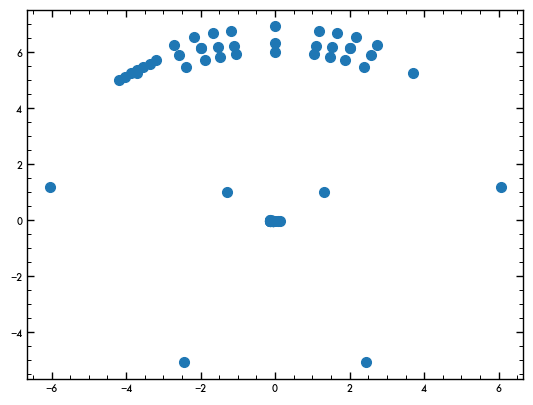

In [88]:
# Reaping all the patterns and saving them into a new CAR171 table.

dX = np.concatenate([dX_primary, dX_dithering_OUT_pos_1a, dX_rogue_half, dX_dithering_IN_POS_4_a, dX_dithering_IN_POS_5_a])
dY = np.concatenate([dY_primary, dY_dithering_OUT_pos_1a, dY_rogue_half, dY_dithering_IN_POS_4_a, dY_dithering_IN_POS_5_a])

plt.scatter(dX, dY)

CAR_id = ["171.2"]*len(dX)
Region = ["Outer stray"]*len(dX)


activity_name_primary = ["OUT_pos_1_a", "OUT_pos_1_b", "OUT_pos_1_c", "OUT_pos_1_d", "OUT_pos_1_e", "OUT_pos_1_f", 
                         "OUT_pos_2_a", "OUT_pos_2_b",
                         "OUT_pos_3_a", "OUT_pos_3_b", 
                         "IN_pos_4_a", "IN_pos_4_b", 
                         "IN_pos_5_a", "IN_pos_5_b"]

notes_primary = ["Secondary mirror leg - 1", "Secondary mirror leg - 2", "Secondary mirror leg - 3", 
                 "Secondary mirror leg - 4", "Secondary mirror leg - 5", "Secondary mirror leg - 6", 
                 "Rogue path central lobe - 1", "Rogue path central lobe - 2",
                 "Inner ring - 1", "Inner ring - 2", 
                 "Center lightshield SCA1", "Center lightshield SCA10", 
                 "Corner lightshield SCA1 - 4","Corner lightshield SCA10 - 13"]


activity_name = activity_name_primary + ["SCAN_RCHANNEL"]*len(dX_dithering_OUT_pos_1a) +\
                ["SCAN_ROGUEPATH"]*len(dX_rogue_half) +\
                ["SCAN_DRAGON1"]*len(dX_dithering_IN_POS_4_a) +\
                ["SCAN_DRAGON2"]*len(dX_dithering_IN_POS_5_a)

lite = ["TRUE"] * len(dX)
possible_descope = ["FALSE"] * len(dX)
MPA_ThetaX = dX
MPA_ThetaY = dY
Target_source = ["Canopus"] * len(dX)
N_FRAME = [55] * len(dX)
N_EXP = [4] * len(dX)
N_FILT = [1] * len(dX)
Time = [14.3] * len(dX)
Filter = ["?"]  * len(dX)
notes = notes_primary + ["Dithering pattern over secondary leg"]*len(dX_dithering_OUT_pos_1a) +\
                ["Rogue path scan"]*len(dX_rogue_half) +\
                ["Central light shield scan"]*len(dX_dithering_IN_POS_4_a) +\
                ["Corner light shield scan"]*len(dX_dithering_IN_POS_5_a)

import pandas as pd
car_171_v2 = pd.DataFrame({"Activity name": activity_name, 
                           "CAR": CAR_id, 
                           "Region": Region, 
                           "Lite?": lite, 
                           "Possible descope": possible_descope, 
                           "MPA_ThetaX": np.round(dX,4), 
                           "MPA_ThetaY": np.round(dY,4), 
                           "Target source":Target_source,
                           "N_FRAME": N_FRAME,
                           "N_EXP": N_EXP,
                           "N_FILT": N_FILT,
                           "Time": Time,
                           "Filter(s)": Filter,
                           "Notes":notes})

car_171_v2.to_csv("CAR171_v2_coordinates.csv")

In [100]:
len(dX_dithering_IN_POS_4_a)

13

In [79]:
len(dX)

68

In [90]:
0.11*4096

450.56

In [99]:
# Add one more target as a NEGATIVE under SCAs 2 and 3, and SCAs 11 and 12 
x1 = (775.39122 - 727.5)*0.0013888888888889
y1 = (601.22418 - 727.5)*0.0013888888888889
x2 = -(775.39122 - 727.5)*0.0013888888888889
y2 = (601.22418  - 727.5)*0.0013888888888889

print(str(x1) + " " + str(y1))
print(str(x2) + " " + str(y2))

0.06651558333333384 -0.17538308333333466
-0.06651558333333384 -0.17538308333333466
